# 第12章 面板数据

## 12.2 面板数据的估计策略

个体效应模型(individual-specific effects model)：
$$
y_{it}=\mathbf{x}^\prime_{it}\mathbf{\beta}+\mathbf{z}^\prime_i\mathbf{\delta}+u_i+\epsilon_{it} \quad (i=1,\cdots,n;t=1,\cdots,T)
$$

- $z_i$为不随时间而变(time invariant)的个体特征(即$z_{it}=z_i,\forall t$),比如性别；
- 而$x_{it}$可以随个体及时间而变(time-varying)。
- 扰动项由($u_i+\epsilon_{it}$)两部分构成，称为复合扰
动项(composite error term)。其中，不可观测的随机变量$u_i$，是代表个体异质性的截距项，即个体效应(individual effects)。扰动项$\epsilon_{it}$既随个体又随时间而变，称为个殊性扰动项(idiosyncratic error)。

如果$u_i$与某个解释变量相关，则进一步称之为固定效应模型(fixed effects model，简记FE)。

如果$u_i$与所有解释变量($\mathbf{x}_{it},\mathbf{z}_i$)均不相关，则进一步称之为随机效应模型(random effects model，简记RE)。

## 12.3 混合回归

如果所有个体都拥有完全一样的回归方程，则$u_1=u_2=\cdots=u_n$。将这些相同的个体效应统一记为$\alpha$，可得：
$$
y_{it}=\alpha+\mathbf{x}^\prime_{it}\mathbf{\beta}+\mathbf{z}^\prime_i\mathbf{\delta}+\epsilon_{it}
$$

此时，可把所有数据放在一起，像对待横截面数据那样进行OLS回归，故称为混合回归(pooled regression)。

由于面板数据的特点，虽然通常可以假设不同个体之间的扰动项相互独立，但同一个体在不同时期的扰动项之间往往存在自相关。此时，每位个体不同时期的所有观测值即构成一个聚类(cluster)。

这样，样本观测值可以分为不同的聚类，在同一聚类里的观测值互相相关，而不同聚类之间的观测值互不相关；这种样本称为聚类样本(cluster sample)。

对于聚类样本，仍可进行OLS估计，但需使用聚类稳健的标准误(cluster-robust standard errors)，在形式上也是一种夹心估计量，只是表达式更为复杂。

## 12.13 面板模型的Stata命令及实例

### 1. 面板数据的设定

设定面板数据的Stata命令为：
```
xtset panelvar timevar
```
命令xtset告诉Stata你的数据为面板数据，其中面板(个体)变量panelvar的取值必须为整数且不重复，相当于将样本中每位个体进行编号；而timevar为时间变量。

假如panelvar本来是字符串(比如，国家名字country)，则可使用以下命令将其转换为数字型变量：
```
encode country,gen(cntry)
```
其中，选择项gen(cntry)表示将新生成的数字型变量记为cntry。

显示面板数据统计特性的Stata命令包括：
```
* 显示面板数据的结构，是否为平衡面板
xtdes
* 显示组内、组间与整体的统计指标
xtsum
* 对每位个体分别显示该变量的时间序列图；如果希望将所有个体的时间序列图叠放在一起，可加上选择项overlay
xtline varname
```

下面以数据集lin_1992.dta为例，该数据集取自Lin(1992)对家庭联产承包责任制(与中国农业增长的经典研究。该省际面板包含中国28个省份1970-1987年有关种植业的数据。被解释变量为lufo(种植业产值对数，1980年为不变价格)。解释变量包括：
- ltlan(耕地面积对数，千亩)
- lwlab(种植业劳动力对数)
- llpow(机械动力与畜力对数，千马力)
- ltfer(化肥使用量对数，千吨)
- hrs(截至年底采用家庭联产承包责任制的生产队比重)
- mipric1(农村消费者价格与农村工业投入品价格之比的一阶滞后，1950年=100)
- giprice(超额收购价格与农村工业投入品价格之比，1950年=100)
- mci(复种指数，播种面积除以耕地面积)
- ngca(非粮食作物占播种面积比重)
- t(时间趋势)
- province(省)
- year(年)

In [1]:
use data/lin_1992.dta,clear
* 首先，设定province与year为面板(个体)变量及时间变量：
xtset province year


Panel variable: province (strongly balanced)
 Time variable: year, 70 to 87
         Delta: 1 unit


In [2]:
* 其次，显示数据集的结构：
xtdes


province:  1, 2, ..., 28                                     n =         28
    year:  70, 71, ..., 87                                   T =         18
           Delta(year) = 1 unit
           Span(year)  = 18 periods
           (province*year uniquely identifies each observation)

Distribution of T_i:   min      5%     25%       50%       75%     95%     max
                        18      18      18        18        18      18      18

     Freq.  Percent    Cum. |  Pattern
 ---------------------------+--------------------
       28    100.00  100.00 |  111111111111111111
 ---------------------------+--------------------
       28    100.00         |  XXXXXXXXXXXXXXXXXX


In [3]:
* 再次，显示数据集中以上变量的统计特征：
xtsum ltvfo ltlan ltwlab ltpow ltfer hrs mipric1 giprice mci ngca


Variable         |      Mean   Std. dev.       Min        Max |    Observations
-----------------+--------------------------------------------+----------------
ltvfo    overall |  7.647758   .5331999       5.51       9.33 |     N =     504
         between |             .4611992   6.982222   8.977222 |     n =      28
         within  |             .2806888    5.61498   8.471647 |     T =      18
                 |                                            |
ltlan    overall |  5.837877   .8084866       4.57       7.76 |     N =     504
         between |             .8143036   4.617222   7.697778 |     n =      28
         within  |             .1138892   4.758988   6.163988 |     T =      18
                 |                                            |
ltwlab   overall |   3.19752   .4193496        .98       3.86 |     N =     504
         between |             .3195715   2.303889   3.646111 |     n =      28
         within  |             .2778123   1.618631   4.053631 |     T =

上表显示，除hrs外，所有变量的观测样本均为28×18=504；而关键变量hrs 的样本容量仅为28×17=476，因为缺失1980年的hrs观测数据。

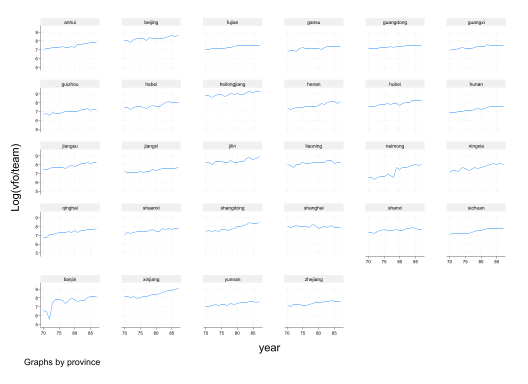

In [4]:
* 下面，查看被解释变量lufo在28个省份的时间趋势图
xtline ltvfo

### 2.混合回归

作为参照系，首先进行混合回归。其Stata命令的基本格式为
```
reg y x1 x2 x3,vce(cluster id)
```
其中，“id”指用来确定每位个体的变量，而选择项“vce(cluster id)”表示以变量“id”作为聚类变量来计算聚类稳健的标准误。

In [5]:
* 选择项“vce(cluster province)”表示以“province”为聚类变量计算聚类稳健标准误。
reg ltvfo ltlan ltwlab ltpow ltfer hrs mipric1 giprice mci ngca,vce(cluster province)
* 将此结果储存，并记为“OLS”。
estimates store OLS


Linear regression                               Number of obs     =        476
                                                F(9, 27)          =      81.39
                                                Prob > F          =     0.0000
                                                R-squared         =     0.8685
                                                Root MSE          =     .19689

                              (Std. err. adjusted for 28 clusters in province)
------------------------------------------------------------------------------
             |               Robust
       ltvfo | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       ltlan |    .693795    .115024     6.03   0.000     .4577853    .9298048
      ltwlab |   .2650224   .0566294     4.68   0.000     .1488285    .3812164
       ltpow |  -.0291884   .0670385    -0.44   0.667    -.1667401    .1083633
       ltfer |

上表显示，关键变量hrs在1%平上显著为正。

In [6]:
* 如果使用普通标准误，则可输入命令：
reg ltvfo ltlan ltwlab ltpow ltfer hrs mipric1 giprice mci ngca


      Source |       SS           df       MS      Number of obs   =       476
-------------+----------------------------------   F(9, 466)       =    342.09
       Model |  119.355964         9  13.2617737   Prob > F        =    0.0000
    Residual |  18.0652415       466  .038766613   R-squared       =    0.8685
-------------+----------------------------------   Adj R-squared   =    0.8660
       Total |  137.421205       475    .2893078   Root MSE        =    .19689

------------------------------------------------------------------------------
       ltvfo | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       ltlan |    .693795   .0368914    18.81   0.000     .6213008    .7662892
      ltwlab |   .2650224   .0238406    11.12   0.000     .2181741    .3118708
       ltpow |  -.0291884   .0331891    -0.88   0.380    -.0944073    .0360305
       ltfer |   .3110617   .0206459    15.07   0.

对比聚类稳健标准误与普通标准误可知，前者均大于后者。由于同一省份不同年之间的扰动项一般存在自相关，而默认的普通标准误计算方法假设扰动项为独立同分布的，故普通标准误的估计并不准确。

### 3. 固定效应

由于每个省份的“省情”不同，可能存在不随时间而变的遗漏变量，故考虑使用固定效应模型(FE)。固定效应模型(组内估计量)的Stata命令格式为：
```
xtreg y x1 x2 x3,fe r
```
- 选择项“fe”表示“fixed effects”(固定效应估计量)，默认“re”表示“random effects”(随机效应估计量)。
- 选择项“r”表示使用聚类稳健标准误；如果使用选择项“vce(cluster id)”也能达到完全相同的效果。

LSDV法的Stata命令为
```
reg y x1 x2 x3 i.id,vce(cluster id)
```
- “id”表示用来确定个体的变量
- “i.id”则表示根据变量“id”而生成的虚拟变量
- 选择项“vce(cluster id)”表示使用聚类稳健标准误

In [7]:
* 首先使用组内估计量，并记其估计结果为“FE_robust”
xtreg ltvfo ltlan ltwlab ltpow ltfer hrs mipric1 giprice mci ngca,fe r
estimates store FE_robust


Fixed-effects (within) regression               Number of obs     =        476
Group variable: province                        Number of groups  =         28

R-squared:                                      Obs per group:
     Within  = 0.8746                                         min =         17
     Between = 0.6483                                         avg =       17.0
     Overall = 0.6993                                         max =         17

                                                F(9, 27)          =     274.25
corr(u_i, Xb) = -0.3877                         Prob > F          =     0.0000

                              (Std. err. adjusted for 28 clusters in province)
------------------------------------------------------------------------------
             |               Robust
       ltvfo | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       ltlan |   .6370234   

上表的输出结果中包括一个常数项“_cons”，这是所有个体效应$u_i$的平均值。上表最后一行显示“rho=0.89”，故复合扰动项($u_i+\epsilon_{it}$)的方差主要来自个体效应$u_i$的变动。

究竟应该使用混合回归还是个体固定效应模型呢？在使用命令“xtreg,fe”时，如果不加选择项“r”(将估计结果记为“FE”)，则输出结果还包含一个F检验，其原假设为“$H_0:所有u_i=0$”，即混合回归是可以接受的：

In [8]:
xtreg ltvfo ltlan ltwlab ltpow ltfer hrs mipric1 giprice mci ngca,fe
estimates store FE


Fixed-effects (within) regression               Number of obs     =        476
Group variable: province                        Number of groups  =         28

R-squared:                                      Obs per group:
     Within  = 0.8746                                         min =         17
     Between = 0.6483                                         avg =       17.0
     Overall = 0.6993                                         max =         17

                                                F(9, 439)         =     340.20
corr(u_i, Xb) = -0.3877                         Prob > F          =     0.0000

------------------------------------------------------------------------------
       ltvfo | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       ltlan |   .6370234   .0673191     9.46   0.000     .5047156    .7693312
      ltwlab |   .1387786   .0261554     5.31   0.000     .08737

由于上表最后一行F检验的p值为0.0000，故强烈拒绝原假设，即认为FE明显优于混合回归，应该允许每位个体拥有自己的截距项。然而，由于未使用聚类稳健标准误，故此F检验并不有效，因为普通标准误均小于聚类稳健标准误。

In [9]:
* 为此，进一步通过LSDV法来考察(将估计结果记为“LSDV”):
reg ltvfo ltlan ltwlab ltpow ltfer hrs mipric1 giprice mci ngca i.province,vce(cluster province)
estimates store LSDV


Linear regression                               Number of obs     =        476
                                                F(8, 27)          =          .
                                                Prob > F          =          .
                                                R-squared         =     0.9642
                                                Root MSE          =     .10589

                              (Std. err. adjusted for 28 clusters in province)
------------------------------------------------------------------------------
             |               Robust
       ltvfo | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       ltlan |   .6370234   .1732267     3.68   0.001     .2815916    .9924553
      ltwlab |   .1387786   .0643506     2.16   0.040     .0067421    .2708151
       ltpow |   .0577152   .0778457     0.74   0.465    -.1020109    .2174414
       ltfer |

从上表可知，不少个体虚拟变量在5%平上显著，故可放心地拒绝“所有个体虚拟变量都为0”的原假设，即认为存在个体固定效应，不应使用混合回归。

安装xtserial
```
net install st0039
```

对于固定效应模型，也可使用一阶差分法(FD)。Stata没有专门执行一阶差分法的命令，但在使用命令“xtserial,output”对组内自相关进行检验时，可附带提供一阶差分法的估计结果(将此结果记为“FD”)：

In [10]:
xtserial ltvfo ltlan ltwlab ltpow ltfer hrs mipric1 giprice mci ngca,output
estimates store FD


Linear regression                               Number of obs     =        420
                                                F(9, 27)          =     902.61
                                                Prob > F          =     0.0000
                                                R-squared         =     0.5797
                                                Root MSE          =     .11179

                              (Std. err. adjusted for 28 clusters in province)
------------------------------------------------------------------------------
             |               Robust
     D.ltvfo | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       ltlan |
         D1. |   .9807158   .0926143    10.59   0.000      .790687    1.170745
             |
      ltwlab |
         D1. |   .2420082   .0734117     3.30   0.003     .0913798    .3926366
             |
       ltpow |
         D1. |  -.

从上表可知，一阶差分估计量(FD)的估计系数与组内估计量(FE)有一定差别。一般认为，FE比FD更有效率，故较少使用FD。

也可以在固定效应模型中考虑时间效应，即双向固定效应(two-way FE),以捕捉技术进步等效应。为节省待估参数，首先考虑加人时间趋势项(将估计结果记为“FE_trend”):

In [11]:
xtreg ltvfo ltlan ltwlab ltpow ltfer hrs mipric1 giprice mci ngca t,fe r
estimates store FE_trend


Fixed-effects (within) regression               Number of obs     =        476
Group variable: province                        Number of groups  =         28

R-squared:                                      Obs per group:
     Within  = 0.8749                                         min =         17
     Between = 0.6490                                         avg =       17.0
     Overall = 0.7006                                         max =         17

                                                F(10, 27)         =     247.93
corr(u_i, Xb) = -0.3767                         Prob > F          =     0.0000

                              (Std. err. adjusted for 28 clusters in province)
------------------------------------------------------------------------------
             |               Robust
       ltvfo | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       ltlan |   .6517195   

其中，时间趋势项t并不显著(p值为0.559)，而主要变量的显著性不变。

In [12]:
* 其次，考虑加入年度虚拟变量。为了演示目的，定义年度虚拟变量：
tab year,gen(year)


       year |      Freq.     Percent        Cum.
------------+-----------------------------------
         70 |         28        5.56        5.56
         71 |         28        5.56       11.11
         72 |         28        5.56       16.67
         73 |         28        5.56       22.22
         74 |         28        5.56       27.78
         75 |         28        5.56       33.33
         76 |         28        5.56       38.89
         77 |         28        5.56       44.44
         78 |         28        5.56       50.00
         79 |         28        5.56       55.56
         80 |         28        5.56       61.11
         81 |         28        5.56       66.67
         82 |         28        5.56       72.22
         83 |         28        5.56       77.78
         84 |         28        5.56       83.33
         85 |         28        5.56       88.89
         86 |         28        5.56       94.44
         87 |         28        5.56      100.00
------------+------

此命令将生成时间虚拟变量year1,year2,⋯,year18。加入年度虚拟变量后，由于两个价格变量mipric1与giprice在各省都一样，故无法包括在回归方程中，以避免严格多重共线性。

In [13]:
* 下面，进行含时间虚拟变量的双向固定效应估计(将结果记为“FE_TW”):
xtreg ltvfo ltlan ltwlab ltpow ltfer hrs mci ngca year2-year18,fe r
estimates store FE_TW

note: year11 omitted because of collinearity.

Fixed-effects (within) regression               Number of obs     =        476
Group variable: province                        Number of groups  =         28

R-squared:                                      Obs per group:
     Within  = 0.8932                                         min =         17
     Between = 0.6596                                         avg =       17.0
     Overall = 0.7156                                         max =         17

                                                F(23, 27)         =     949.82
corr(u_i, Xb) = -0.3425                         Prob > F          =     0.0000

                              (Std. err. adjusted for 28 clusters in province)
------------------------------------------------------------------------------
             |               Robust
       ltvfo | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+-----------------------------------------------

year1(即1970年)被作为基期(对应于常数项_cons)，而不包括在上述回归命令中(否则，将出现虚拟变量陷阱，导致完全多重共线性)。另外，由于1980年的hrs数据缺失，故year11(即1980年)也被去掉。即使在双向固定效应模型中，hrs也依然在5%平上显著为正。另一方面，大多数的年度虚拟变量均不显著(但year3在1%平上显著)。

In [14]:
* 下面检验所有年度虚拟变量的联合显著性：
test year2 year3 year4 year5 year6 year7 year8 year9 year10 year12 year13 year14 year15 year16 year17 year18


 ( 1)  year2 = 0
 ( 2)  year3 = 0
 ( 3)  year4 = 0
 ( 4)  year5 = 0
 ( 5)  year6 = 0
 ( 6)  year7 = 0
 ( 7)  year8 = 0
 ( 8)  year9 = 0
 ( 9)  year10 = 0
 (10)  year12 = 0
 (11)  year13 = 0
 (12)  year14 = 0
 (13)  year15 = 0
 (14)  year16 = 0
 (15)  year17 = 0
 (16)  year18 = 0

       F( 16,    27) =   14.82
            Prob > F =    0.0000


结果强烈拒绝“无时间固定效应”的原假设，认为应在模型中包括时间固定效应。

In [15]:
* 在Stata中，还可直接用以下命令来估计双向固定效应模型(不必先生成时间虚拟变量):
* “i.year”表示根据变量year的不同取值来生成年度虚拟变量。
xtreg ltvfo ltlan ltwlab ltpow ltfer hrs mci ngca i.year,fe r


Fixed-effects (within) regression               Number of obs     =        476
Group variable: province                        Number of groups  =         28

R-squared:                                      Obs per group:
     Within  = 0.8932                                         min =         17
     Between = 0.6596                                         avg =       17.0
     Overall = 0.7156                                         max =         17

                                                F(23, 27)         =     949.82
corr(u_i, Xb) = -0.3425                         Prob > F          =     0.0000

                              (Std. err. adjusted for 28 clusters in province)
------------------------------------------------------------------------------
             |               Robust
       ltvfo | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       ltlan |   .5833594   

### 4.随机效应

随机效应估计的Stata命令为
```
xtreg y x1 x2 x3,re r theta
```
- 选择项“re”为默认选项(可省略)
- 选择项“r”表示使用聚类稳健标准误，如果使用选择项“vce(cluster id)”也能达到完全相同的效果。
- 选择项“theta”表示显示用于进行广义离差变换的$\theta$值。

对于随机效应模型，也可以进行MLE估计，其Stata命令为
```
xtreg y x1 x2 x3,mle
```

In [16]:
* 下面，进行随机效应(RE)的估计(将结果记为“RE_robust”):
xtreg ltvfo ltlan ltwlab ltpow ltfer hrs mci ngca,re r theta
estimates store RE_robust


Random-effects GLS regression                   Number of obs     =        476
Group variable: province                        Number of groups  =         28

R-squared:                                      Obs per group:
     Within  = 0.8700                                         min =         17
     Between = 0.8135                                         avg =       17.0
     Overall = 0.8263                                         max =         17

                                                Wald chi2(7)      =    2452.50
corr(u_i, X) = 0 (assumed)                      Prob > chi2       =     0.0000
theta        = .81012778

                              (Std. err. adjusted for 28 clusters in province)
------------------------------------------------------------------------------
             |               Robust
       ltvfo | Coefficient  std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
   

上表最后三行显示，$\sigma_u=0.13324845$，$\sigma_e=0.10624809$，而$\rho=\frac{\sigma_u^2}{\sigma_u^2+\sigma_e^2}=0.6113231$

究竟应使用混合回归，还是个体随机效应模型？Breusch和Pagan提供了一个检验个体随机效应的LM检验，其原假设为“$H_0:\sigma_u^2=0$”，而备择假设为“$H_1:\sigma_u^2\neq 0$”。如果拒绝$H_0$，则说明原模型中应该有一个反映个体特性的随机扰动项$u_i$，而不应该使用混合回归。

该LM检验的Stata命令为“xttest0”(在执行命令“xtreg,re”之后才能进行)。

In [17]:
xttest0


Breusch and Pagan Lagrangian multiplier test for random effects

        ltvfo[province,t] = Xb + u[province] + e[province,t]

        Estimated results:
                         |       Var     SD = sqrt(Var)
                ---------+-----------------------------
                   ltvfo |   .2893078       .5378734
                       e |   .0112887       .1062481
                       u |   .0177551       .1332484

        Test: Var(u) = 0
                             chibar2(01) =  1235.75
                          Prob > chibar2 =   0.0000


上表显示，LM检验强烈拒绝“不存在个体随机效应”的原假设(p值为0.0000)，即认为在“随机效应”与“混合回归”二者之间，应该选择“随机效应”。

In [18]:
* 下面，看一下使用普通标准误的随机效应估计结果(将结果记为“RE”)。
xtreg ltvfo ltlan ltwlab ltpow ltfer hrs mci ngca,re 
estimates store RE


Random-effects GLS regression                   Number of obs     =        476
Group variable: province                        Number of groups  =         28

R-squared:                                      Obs per group:
     Within  = 0.8700                                         min =         17
     Between = 0.8135                                         avg =       17.0
     Overall = 0.8263                                         max =         17

                                                Wald chi2(7)      =    2981.73
corr(u_i, X) = 0 (assumed)                      Prob > chi2       =     0.0000

------------------------------------------------------------------------------
       ltvfo | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
       ltlan |   .5655915   .0478214    11.83   0.000     .4718633    .6593196
      ltwlab |   .1441844   .0233398     6.18   0.000     .09843

In [19]:
* 作为对照，也可以对随机效应模型进行MLE估计(将结果记为“MLE”):
xtreg ltvfo ltlan ltwlab ltpow ltfer hrs mci ngca,mle nolog
estimates store MLE


Random-effects ML regression                         Number of obs    =    476
Group variable: province                             Number of groups =     28

Random effects u_i ~ Gaussian                        Obs per group:
                                                                  min =     17
                                                                  avg =   17.0
                                                                  max =     17

                                                     LR chi2(7)       = 961.00
Log likelihood = 332.89739                           Prob > chi2      = 0.0000

------------------------------------------------------------------------------
       ltvfo | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
       ltlan |   .5643288   .0518396    10.89   0.000      .462725    .6659326
      ltwlab |   .1408974   .0235161     5.99   0.000     .

上表显示，随机效应MLE的系数估计值与随机效应FGLS有所不同，但在性质上依然类似。另外，上表最后一行的LR检验强烈拒绝原假设“$H_0:\sigma_u=0$”,即认为存在个体随机效应，不应进行混合回归。

### 5.固定效应还是随机效应：豪斯曼检验

豪斯曼检验的Stata命令为
```
* 固定效应估计
xtreg y x1 x2 x3,fe
* 存储结果
estimates store FE
* 随机效应估计
xtreg y x1 x2 x3,re
* 存储结果
estimates store RE
* 豪斯曼检验
hausman FE RE,constant sigmamore
```
- 选择项“constant”表示在比较系数估计值时包括常数项(默认不含常数项)
- 选择项“sigmamore”表示统一使用更有效率的那个估计量(即随机效应估计量)的方差估计

In [20]:
* 由于前面已存储了相应的估计结果，故可直接进行豪斯曼检验。
hausman FE RE,constant sigmamore


                 ---- Coefficients ----
             |      (b)          (B)            (b-B)     sqrt(diag(V_b-V_B))
             |       FE           RE         Difference       Std. err.
-------------+----------------------------------------------------------------
       ltlan |    .6370234     .5655915        .0714319        .0522174
      ltwlab |    .1387786     .1441844       -.0054059        .0145627
       ltpow |    .0577152      .060477       -.0027618        .0241549
       ltfer |    .1826281     .1882741        -.005646        .0100505
         hrs |    .2134022     .2186096       -.0052075        .0091613
         mci |    .1943697     .4702368       -.2758671        .0657487
        ngca |    .7562031     .6745175        .0816856         .083631
       _cons |    2.337895     2.387878       -.0499825        .2834941
------------------------------------------------------------------------------
                          b = Consistent under H0 and Ha; obtained from xtr

由于p值为0.0000，故强烈拒绝原假设“$H_0$:$u_i$与解释变量不相关”，认为应该使用固定效应模型，而非随机效应模型。

下载非官方命令“xtoverid”进行稳健的豪斯曼检验
```
ssc install xtoverid
```

In [21]:
* 在使用命令“xtoverid”之前，须先以稳健标准误来执行命令“xtreg,re”。
quietly xtreg ltvfo ltlan ltwlab ltpow ltfer hrs mci ngca,r
xtoverid


Test of overidentifying restrictions: fixed vs random effects
Cross-section time-series model: xtreg re  robust cluster(province)
Sargan-Hansen statistic 221.225  Chi-sq(7)    P-value = 0.0000


上表显示，$\chi^22(7)$统计量为221.225，p值为0.0000，故仍然强烈拒绝“随机效应”的原假设。

### 6.组间估计量

In [22]:
* 下面进行组间估计。
xtreg ltvfo ltlan ltwlab ltpow ltfer hrs mci ngca,be


Between regression (regression on group means)  Number of obs     =        476
Group variable: province                        Number of groups  =         28

R-squared:                                      Obs per group:
     Within  = 0.4673                                         min =         17
     Between = 0.9362                                         avg =       17.0
     Overall = 0.0232                                         max =         17

                                                F(7,20)           =      41.93
sd(u_i + avg(e_i.)) = .1357173                  Prob > F          =     0.0000

------------------------------------------------------------------------------
       ltvfo | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       ltlan |   .7021718   .1177241     5.96   0.000     .4566037    .9477398
      ltwlab |   .5020747   .0940029     5.34   0.000     .30598

由于豪斯曼检验选择了固定效应，而组间估计量仅在随机效应成立的情况下才一致，故组间估计的结果并不可信。例如，根据组间估计量，hrs在1%平上显著为负，即家庭联产承包责任制反而对种植业产值有负作用。

In [23]:
* 下面，将以上各主要方法的回归系数及标准误列表
esttab OLS FE_robust FE_trend FE RE,b se mtitle


-------------------------------------------------------------------------------
> -------------
                      (1)             (2)             (3)             (4)      
>        (5)   
                      OLS       FE_robust        FE_trend              FE      
>         RE   
-------------------------------------------------------------------------------
> -------------
ltlan               0.694***        0.637***        0.652**         0.637***   
>      0.566***
                  (0.115)         (0.168)         (0.184)        (0.0673)      
>   (0.0478)   

ltwlab              0.265***        0.139*          0.143*          0.139***   
>      0.144***
                 (0.0566)        (0.0625)        (0.0589)        (0.0262)      
>   (0.0233)   

ltpow             -0.0292          0.0577          0.0366          0.0577      
>     0.0605*  
                 (0.0670)        (0.0756)        (0.0991)        (0.0333)      
>   (0.0253)   

ltfer               0.311***        

从上表可知，无论使用何种方法，家庭联产承包责任制(hrs)均在1%水平上对各省份种植业产值有显著的正效应。